In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from rl_setup import STEM_environment, simulation_parameters, simulate_haadf, system, hf_energy_stack, laplacian_energy_stack
import os
%matplotlib widget
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"  # consistent GPU ordering
os.environ["CUDA_VISIBLE_DEVICES"] = str(0)
os.environ["OMP_NUM_THREADS"] = "1"


2025-11-12 13:30:57.450966: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 13:30:57.460824: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762983057.473758  340700 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762983057.477877  340700 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762983057.488059  340700 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 


# In this notebook we test the state space simulations and focus metrics.

- Henry Bell, updated 11/11/2025

In [7]:
# defocus series
defoci = np.linspace(-100,100,7)
imgs = []
for defocus in defoci:
    haadf_image = simulate_haadf(
        system = system, 
        sampling = simulation_parameters["sampling"],
        inner_angle = simulation_parameters["inner_angle"],
        outer_angle = simulation_parameters["outer_angle"],
        semi_angle_cutoff = 20, #mrad standard
        crop_size = simulation_parameters["crop_size"],
        center_x = simulation_parameters["center_x"],
        center_y = simulation_parameters["center_y"],
        aberation_dict = {"C10": defocus},
        interpolation_sampling=simulation_parameters["interpolation_sampling"],
        dose_rate = 1e7
    )
    imgs.append(haadf_image)

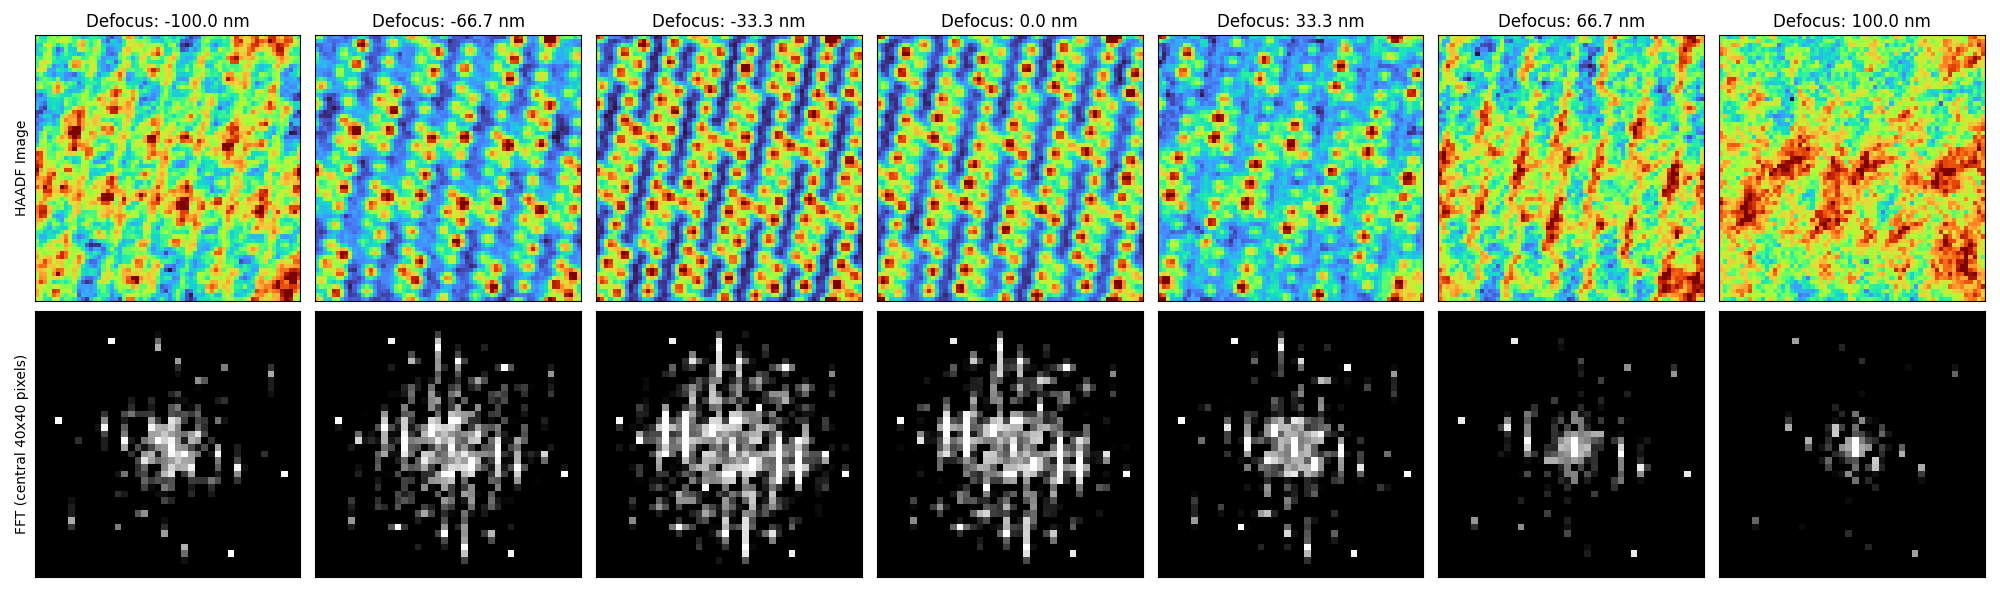

In [8]:
fig, ax = plt.subplots(2,7, figsize=(20,6))

for i in range(defoci.size):
    ax[0,i].imshow(imgs[i], cmap='turbo')
    ax[0,i].set_title(f'Defocus: {defoci[i]:.1f} nm')
    ax[0,i].set_xticks([])
    ax[0,i].set_yticks([])

    FFT = np.fft.fft2(imgs[i])
    FFT_shifted = np.fft.fftshift(FFT)
    ax[1,i].imshow(np.log(np.abs(FFT_shifted))[64//2 - 20:64//2 + 20,64//2 - 20:64//2 + 20], cmap='grey', vmin = 2, vmax=4)
    ax[1,i].set_xticks([])
    ax[1,i].set_yticks([])

ax[0,0].set_ylabel('HAADF Image')
ax[1,0].set_ylabel('FFT (central 40x40 pixels)')
fig.tight_layout()

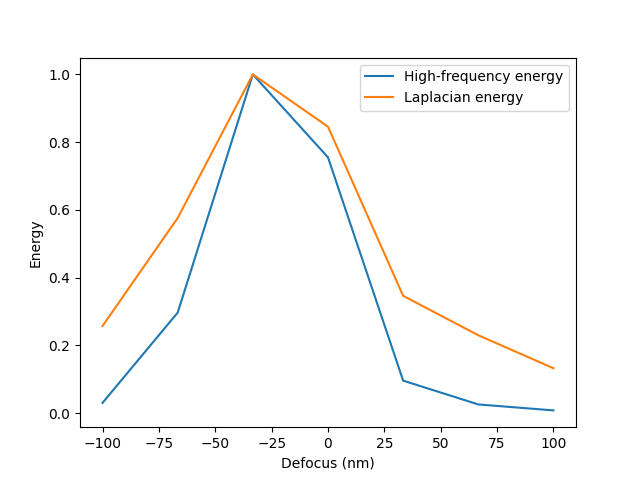

In [9]:
hf_score = hf_energy_stack(np.array(imgs), k_cut = 0.1)
lap_score = laplacian_energy_stack(np.array(imgs), sigma = 1)

fig, ax = plt.subplots()
ax.plot(defoci, hf_score/hf_score.max(), label='High-frequency energy')
ax.plot(defoci, lap_score/lap_score.max(), label='Laplacian energy')
ax.set_xlabel('Defocus (nm)')
ax.set_ylabel('Energy')
ax.legend()

In [10]:
hf_score[:-1] - hf_score[1:]

array([-0.04933353, -0.13021222,  0.04535983,  0.1220408 ,  0.01301752,
        0.00325686])